# Logistic Regression
This is a hypothesis class for binary classification, mainly. The governing equation is very similar to a linear classifier.

$$z = (\theta_1 x_1 + \theta_2 x_2 + ... + \theta_d x_d) + \theta_0$$

We squish $z$ with a sigmoid/logistic function:

$$g = \sigma(z) = \frac{1}{1+\text{exp}(-z)}$$

This sigmoid function is constrained to (0.0, 1.0) therefore allowing us to interpret the output as a probability that a certain $x$ is classified as that class.

We predict the class using a simple threshold: if $g > 0.5$, predict positive class. Otherwise, predict negative class.

## Notes on sigmoid function
- Vertically, always monotonically "sandwiched" between 0 and 1
- Probabilistic interpretation
- Very nice/elegant gradient, good for gradient descent!
- With appropriate $\theta, \theta_0$ we can horizontally flip, squeeze, expand, or shift the sigmoid, thus giving us interesting ways to manipulate the function

## Okay, great. So how should we learn the correct sigmoid classifier?

Intuitively, if we see a training datum $i$ with $y^{(i)} = 1$, we want $g^{(i)}$ to be high. If we see a training datum $i$ with $y^{(i)} = 0$, we want $1 - g^{(i)}$ to be high. (Likelihood)

We can combine these two into one equation: we want $g^{(i) y^{(i)}}(1 - g^{(i)})^{1 - y^{(i)}}$ to be high for the $i$ th training datum.

Let's take the logarithm, as it is monotonic: we want $y^{(i)} \log g^{(i)} + (1 - y^{(i)})\log (1 - g^{(i)})$ to be high for the $i$ th training datum. (Log likelihood)

To turn this into a loss, we add a negative sign, since we want to minimize the loss over training. (Negative log likelihood)

$$\mathcal{L}_{\text{nll}} (g^{(i)}, y^{(i)}) = \mathcal{L}_{\text{nll}} (\text{guess}, \text{actual}) = - (y^{(i)} \log g^{(i)} + (1 - y^{(i)})\log (1 - g^{(i)}))$$

Finally, we want this to be low for all data points, so we want to minimize:

$$ \mathcal{J}_{\text{lr}} = \frac{1}{n} \sum_{i = 1}^{n} \mathcal{L}_{\text{nll}} (g^{(i)}, y^{(i)}) = \frac{1}{n} \sum_{i = 1}^{n} \mathcal{L}_{\text{nll}} (\sigma(\theta^Tx^{(i)} + \theta_0), y^{(i)}) = \frac{1}{n} \sum_{i = 1}^{n} - (y^{(i)} \log g^{(i)} + (1 - y^{(i)})\log (1 - g^{(i)})) $$

This is our final loss function. WAHOO!


### Sidebar: What is the core difference between probability and likelihood?
Probability predicts the chance of future outcomes based on a known model, while likelihood assesses the plausibility of different model parameters based on observed data. 

Two example questions:
1. Given that $\mu = 13$ and $\sigma = 2$, what is the probability that $5 \leq x \leq 10$? 
2. What is the likelihood that $\mu = 13$ and $\sigma = 2$ if you observed a value of $x=10$? 

These answer to these two questions is different because probability is "forward looking" (given a model, what data will I see) whereas likelihood is "backward looking" (given this data, what model parameters are most plausible?).

## What is "cross-entropy loss"?

We just solved it! 

$$ \mathcal{J}_{\text{lr}} = \frac{1}{n} \sum_{i = 1}^{n} \mathcal{L}_{\text{nll}} (\sigma(\theta^Tx^{(i)} + \theta_0), y^{(i)}) $$

This is convex and differentiable with elegant gradients, making it optimal for gradient descent.

## There is one gotcha.
When training data is linearly separable, we can keep increasing $\theta$ to create a step-like function and assign all points as being either 0 or 1. This leads to an unbounded and overfitted model. Thus, we introduce regularization!

$$ \mathcal{J}_{\text{lr}} = (\frac{1}{n} \sum_{i = 1}^{n} \mathcal{L}_{\text{nll}} (\sigma(\theta^Tx^{(i)} + \theta_0), y^{(i)})) + \lambda||\theta||^2 $$

Here, we note:
- $\lambda \geq 0$
- We don't regularize $\theta_0$, the bias term, because it serves as an offset, not a feature multiplier. Regularization serves to penalize large feature weights. Having a large bias term may be necessary for the most accurate fitted model, so forcing it to be close to 0 may end up with an underfit model.
- The regularization penalizes overfitting, since if you have extremely large $\theta$, this could denote an overly certain, step-like function.
- The objective is still differentiable and convex, allowing for gradient descent. HOORAY!

## Question: Can logistic regression be used for multi-class classification?

We can use one-hot vectors to denote class labels for multi-class. We generalize the sigmoid to softmax, and generalize the negative log likelihood to negative log likelihood multiclass (or just cross entropy).

Every data point incurs a scalar loss.

In binary classification (two classes), $$z = \theta^Tx + \theta_0$$ produces a scalar value. The sigmoid then is also a scalar.

In multi-class classification (K classes), we have $$z = \theta^Tx + \theta_0$$ producing a K x 1 vector. $$ g = \text{softmax}(z)$$ is a K x 1 vector where each item $i$ is $$\text{exp}(z_i) / \sum_i\text{exp}(z_i)$$. The vector gives you the predicted likelihood that the object $i$ falls into each of the $K$ classes.

Finally, the cross-entropy loss is:
$$\mathcal{L}_{\text{nllm}}(g,y) = - \sum_{k=1}^{K}y_k \cdot \text{log}(g_k)$$

## Okay, awesome. Let's implement it!
The plan:
1. Synthesize data first -- let's generate linearly separable 2D data so we can visualize the decision boundary.
   1. Attempt without regularization, and with regularization.
2. Implement the forward pass.
3. Implement the backward pass.
4. Gradient descent loop
5. Visualize

## Using numpy first to hand-calculate the backpropagation

In [1]:
import matplotlib.pyplot as plt
import numpy as np

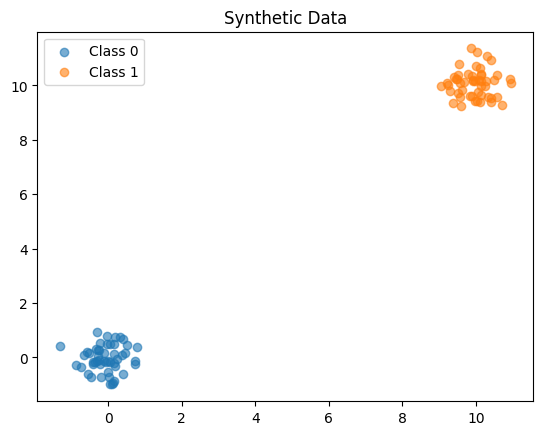

In [2]:
"""
Let's generate data that is linearly separable for this first example.
We want 2D features so we can visualize the separation.
We sample from two gaussians. in order to increase their chances of being linearly separable, we 
set them to have small standard deviations (0.5) and for their means to be far apart [0,0] and [10, 10].
"""
np.random.seed(42)

# class 0: centered at [0, 0]
# class 1: centered at [10, 10]
# 50 points each, std=0.5

class0 = np.random.randn(50, 2) * 0.5
class1 = np.random.randn(50, 2) * 0.5 + 10

# combine into X and y
X = np.vstack([class0, class1]) # shape (100, 2)
y = np.hstack([np.zeros(50), np.ones(50)]) # shape (100,)

# we use hstack, not vstack for y because vstack returns a vector of shape (2, 50)

# plot to visualize
plt.scatter(X[y==0, 0], X[y==0, 1], label="Class 0", alpha=0.6)
plt.scatter(X[y==1, 0], X[y==1, 1], label="Class 1", alpha=0.6)
plt.legend()
plt.title("Synthetic Data")
plt.show()

Equations that may be useful for implementing the model:

The governing equation is very similar to a linear classifier.

$$z = (\theta_1 x_1 + \theta_2 x_2 + ... + \theta_d x_d) + \theta_0$$
    
We squish $z$ with a sigmoid/logistic function:

$$g = \sigma(z) = \frac{1}{1+\text{exp}(-z)}$$

We want to minimize:

$$\mathcal{L}_{\text{nll}} (g^{(i)}, y^{(i)}) = \mathcal{L}_{\text{nll}} (\text{guess}, \text{actual}) = - (y^{(i)} \log g^{(i)} + (1 - y^{(i)})\log (1 - g^{(i)}))$$

Applied to all data points:

$$ \mathcal{J}_{\text{lr}} = \frac{1}{n} \sum_{i = 1}^{n} \mathcal{L}_{\text{nll}} (g^{(i)}, y^{(i)}) = \frac{1}{n} \sum_{i = 1}^{n} \mathcal{L}_{\text{nll}} (\sigma(\theta^Tx^{(i)} + \theta_0), y^{(i)}) = \frac{1}{n} \sum_{i = 1}^{n} - (y^{(i)} \log g^{(i)} + (1 - y^{(i)})\log (1 - g^{(i)})) $$

This is our final loss function.

In [5]:
"""
Let's build the actual logistic regression model. Starting with the forward pass!
"""
def sigmoid(z):
    """
    Compute the sigmoid function.
    z: array of shape (n,)
    returns: array of shape (n,) with values in [0, 1]
    """
    return 1 / (1 + np.exp(-z))

def predict(X, w, b):
    """
    Compute predictions.
    X: shape (n, 2) - features
    w: shape (2,) - weights
    b: scalar - bias
    returns: array of shape (n,) - predicted probabilities
    """
    # first compute the linear prediction
    z = (X @ w) + b
    # then compute the sigmoid
    return sigmoid(z)

def compute_loss(X, y, w, b):
    """
    Compute binary cross entropy loss (negative log-likelihood with two classes)
    X: shape (n, 2) - features
    y: shape (n,) - true labels (0 or 1)
    w: shape (2,) - weights
    b: scalar - bias
    returns: scalar loss
    """
    # first compute the predicted y
    y_pred = predict(X, w, b)
    # grab the number of features
    n = X.shape[0]
    # compute the binary cross entropy averaged across all data points
    return -1/n * np.sum(y * np.log(y_pred) + (1-y) * np.log(1-y_pred))

## Hand-calculate the backpropagation gradients.
This is a good learning exercise to refresh your derivative rules and ensure you understand why certain gradients resolve nicely!

1. Solve $\frac{\partial^2 \mathcal{L}}{\partial z}$ for a single example.
2. Solve $\frac{\partial^2 \mathcal{L}}{\partial w}$.
3. Solve $\frac{\partial^2 \mathcal{L}}{\partial b}$.

Answers to the above:
1. 

\begin{align}
\frac{\partial^2 \mathcal{L}}{\partial z} &= \\
&= -[y_i \frac{\partial}{\partial z_i}[\log(\sigma(z_i))] + (1-y_i) \frac{\partial}{\partial z_i}[\log(1-\sigma(z_i))]] \\
&= -[y_i (1 - \sigma(z_i)) + (1-y_i) (-\sigma(z_i))] \\
&= -y_i + \sigma(z_i) \\
\end{align}

It's a good exercise to rederive $\sigma'(z) = \sigma(z) (1-\sigma(z))$.

2. 

\begin{align}
\frac{\partial^2 \mathcal{L}}{\partial w} &= \\
&= \frac{1}{n}\sum_{i=1}^{n}[-y_i + \sigma(z_i)] * x_i
\end{align}

3. 

\begin{align}
\frac{\partial^2 \mathcal{L}}{\partial b} &= \\
&= -y_i + \sigma(z_i)
\end{align}

In [4]:
"""
Next is the backward pass.
"""
def compute_gradients(X, y, w, b):
    """
    Compute gradients of loss w.r.t. w and b.
    X: shape (n, 2)
    y: shape (n,)
    w: shape (2)
    b: scalar
    returns (grad_w, grad_b) where grad_w has shape (2,) and grad_b is a scalar
    """
    n = X.shape[0]

    # Compute predictions
    pred_y = predict(X, w, b)

    # Compute error
    error = pred_y - y # shape (n,)

    # Compute gradients, which are averaged over all samples
    grad_w = (1/n) * X.T @ error # shape (2,)
    grad_b = (1/n) * np.sum(error) # scalar

    return grad_w, grad_b

Iteration 1: Loss = 0.6843
Iteration 101: Loss = 0.1025
Iteration 201: Loss = 0.0552
Iteration 301: Loss = 0.0371
Iteration 401: Loss = 0.0278
Iteration 501: Loss = 0.0222
Iteration 601: Loss = 0.0184
Iteration 701: Loss = 0.0158
Iteration 801: Loss = 0.0137
Iteration 901: Loss = 0.0122


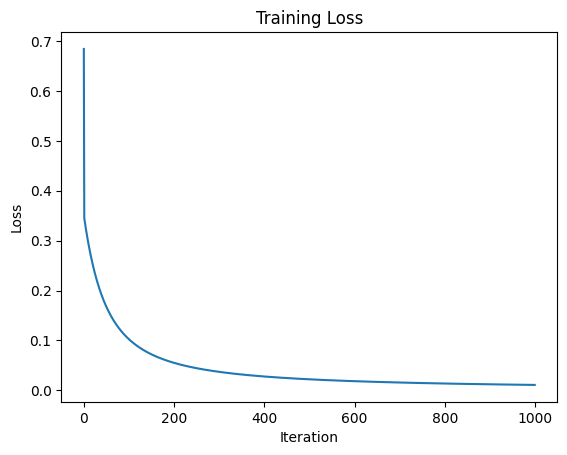

Final accuracy: 100.00%


In [7]:
"""
Great, now let's write the gradient descent loop.
"""
# Initialize parameters
np.random.seed(42)
w = np.random.randn(2) * 0.01 # small random initialization which will later be tweaked
b = 0.0

# Hyperparameters
learning_rate = 0.1
n_iterations = 1000

# Track losses over time
losses = []

for i in range(n_iterations):
    # Compute loss
    loss = compute_loss(X, y, w, b)
    losses.append(loss)

    # Compute gradients
    grad_w, grad_b = compute_gradients(X, y, w, b)

    # Update parameters
    w = w - learning_rate * grad_w
    b = b - learning_rate * grad_b

    # Print progress
    if i % 100 == 0:
        print(f"Iteration {i+1}: Loss = {loss:.4f}")
    
# Plot loss curve
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

# Final accuracy
final_preds = predict(X, w, b)
accuracy = np.mean((final_preds > 0.5) == y)
print(f"Final accuracy: {accuracy:.2%}")

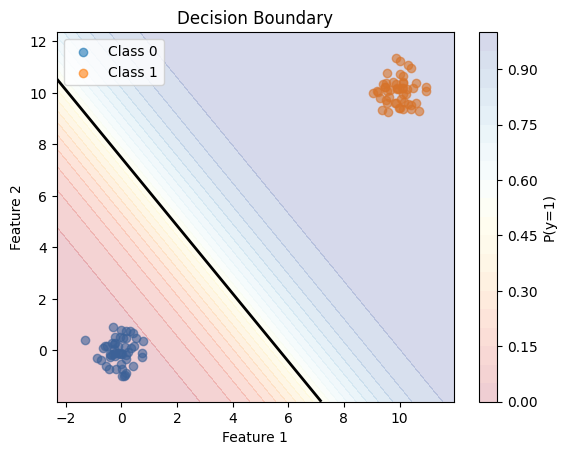

In [8]:
"""
Finally, let's visualize the decision boundary.
"""
def plot_decision_boundary(X, y, w, b):
    """
    Plot data points and decision boundary.
    """
    # Plot data points
    plt.scatter(X[y==0, 0], X[y==0, 1], label='Class 0', alpha=0.6)
    plt.scatter(X[y==1, 0], X[y==1, 1], label='Class 1', alpha=0.6)
    
    # Create a mesh to plot decision boundary
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    # Predict on mesh points
    mesh_points = np.c_[xx.ravel(), yy.ravel()]
    Z = predict(mesh_points, w, b)
    Z = Z.reshape(xx.shape)
    
    # Plot decision boundary (where probability = 0.5)
    plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
    
    # Optional: show probability regions
    plt.contourf(xx, yy, Z, levels=20, alpha=0.2, cmap='RdYlBu')
    
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.title('Decision Boundary')
    plt.colorbar(label='P(y=1)')
    plt.show()

# Plot it
plot_decision_boundary(X, y, w, b)

In [9]:
print(f"Final learned weights: {w}")
print(f"Final learned bias: {b}")

Final learned weights: [0.67546707 0.51194603]
Final learned bias: -3.8346703562621944


## Awesome! Now let's implement L2 (ridge) regularization and see how the learning changes.
This is the loss function with L2 regularization.

$$ \mathcal{J}_{\text{lr}} = (\frac{1}{n} \sum_{i = 1}^{n} \mathcal{L}_{\text{nll}} (\sigma(\theta^Tx^{(i)} + \theta_0), y^{(i)})) + \lambda||\theta||^2 $$

To have nice clean gradients, you'll see the factor $\frac{1}{2}$ in front of the regularization term. This is because the gradient of $\lambda||\theta||^2$ is $2\lambda \theta$, but with the factor included, it's simply $\lambda \theta$.

In [11]:
"""
Implement L2 regularization.
"""
def compute_loss_regularized(X, y, w, b, lambda_val):
    """
    Compute binary cross entropy loss (negative log-likelihood with two classes) with L2 regularization.
    X: shape (n, 2) - features
    y: shape (n,) - true labels (0 or 1)
    w: shape (2,) - weights
    b: scalar - bias
    lambda_val: scalar - regularization hyperparameter
    returns: scalar loss
    """
    # first compute the predicted y
    y_pred = predict(X, w, b)
    # grab the number of features
    n = X.shape[0]
    # compute the binary cross entropy averaged across all data points
    return -1/n * np.sum(y * np.log(y_pred) + (1-y) * np.log(1-y_pred)) + (1/2) * lambda_val * w.T @ w

def compute_gradients_regularized(X, y, w, b, lambda_val):
    """
    Compute gradients of loss w.r.t. w and b.
    X: shape (n, 2)
    y: shape (n,)
    w: shape (2,)
    b: scalar
    lambda_val: scalar - regularization hyperparameter
    returns (grad_w, grad_b) where grad_w has shape (2,) and grad_b is a scalar
    """
    n = X.shape[0]

    # Compute predictions
    pred_y = predict(X, w, b)

    # Compute error
    error = pred_y - y # shape (n,)

    # Compute gradients, which are averaged over all samples
    grad_w = (1/n) * X.T @ error + lambda_val * w # shape (2,)
    grad_b = (1/n) * np.sum(error) # scalar

    return grad_w, grad_b

Lambda: 0.0
λ=  0.00 | Loss=0.1029 | Acc=100.00% | ||w||=0.5544
Lambda: 0.01
λ=  0.01 | Loss=0.1046 | Acc=100.00% | ||w||=0.5366
Lambda: 0.1
λ=  0.10 | Loss=0.1170 | Acc=100.00% | ||w||=0.4522
Lambda: 1.0
λ=  1.00 | Loss=0.1851 | Acc=100.00% | ||w||=0.3126
Lambda: 10.0
λ= 10.00 | Loss=0.4119 | Acc=100.00% | ||w||=0.1527


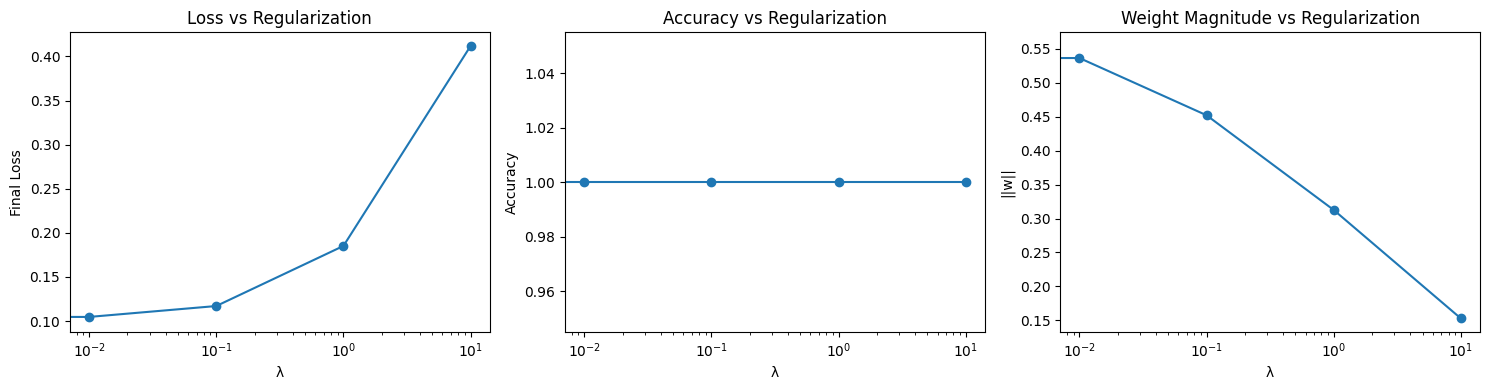

In [12]:
# Test different lambdas
lambda_values = [0.0, 0.01, 0.1, 1.0, 10.0]
results = []

# Hyperparams
n_iterations = 1000
learning_rate = 0.01

for lambda_val in lambda_values:
    print(f"Lambda: {lambda_val}")
    # Initialize params
    np.random.seed(42)
    w = np.random.randn(2) * 0.01
    b = 0.0

    losses = []
    for i in range(n_iterations):
        loss = compute_loss_regularized(X, y, w, b, lambda_val)
        losses.append(loss)

        # Compute gradient
        grad_w, grad_b = compute_gradients_regularized(X, y, w, b, lambda_val)

        # Update parameters
        w = w - grad_w * learning_rate
        b = b - grad_b * learning_rate

    # Evaluate
    final_loss = compute_loss_regularized(X, y, w, b, lambda_val)
    final_preds = predict(X, w, b)
    accuracy = np.mean((final_preds > 0.5) == y)
    weight_magnitude = np.linalg.norm(w)
    
    results.append({
        'lambda': lambda_val,
        'loss': final_loss,
        'accuracy': accuracy,
        'weight_norm': weight_magnitude
    })
    
    print(f"λ={lambda_val:6.2f} | Loss={final_loss:.4f} | Acc={accuracy:.2%} | ||w||={weight_magnitude:.4f}")

# Visualize the effect
import pandas as pd
df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(df['lambda'], df['loss'], marker='o')
axes[0].set_xlabel('λ')
axes[0].set_ylabel('Final Loss')
axes[0].set_xscale('log')
axes[0].set_title('Loss vs Regularization')

axes[1].plot(df['lambda'], df['accuracy'], marker='o')
axes[1].set_xlabel('λ')
axes[1].set_ylabel('Accuracy')
axes[1].set_xscale('log')
axes[1].set_title('Accuracy vs Regularization')

axes[2].plot(df['lambda'], df['weight_norm'], marker='o')
axes[2].set_xlabel('λ')
axes[2].set_ylabel('||w||')
axes[2].set_xscale('log')
axes[2].set_title('Weight Magnitude vs Regularization')

plt.tight_layout()
plt.show()

As you can see, the regularization was successful in the sense that it decreased the weight magnitude with larger values of $\lambda$. At the same time, since the data is perfectly linearly separable, this means that the accuracy was unchanged no matter the $\lambda$. Finally, the loss does increase with $\lambda$. Even though the weight magnitude is smaller, we are adding a larger penalty because it is multiplied by $\lambda$. This is the case where the penalty term dominates the loss, since the cross-entropy loss is already incredibly small. 

With regularization, you are provoking the trade-off between fitting the training data (cross-entropy term) and keeping weights small (regularization term).

For perfectly separable data, there is no risk of overfitting, so regularization only hurts. But when we have noisy data, when we want to generalize, then regularization does help generalize to unseen data. 

## Final remarks
We made it! I'm really proud of myself, because every cell in this notebook helps cement my understanding of basic machine learning concepts (logistic regression, gradient descent, L2 regularization) and helps me practice with the NumPy API.